In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
from functools import partial
import re

# Plotting
import matplotlib.pyplot as plt

In [2]:
# Define lat/lon ranges and region name for entire notebook
lat_start, lat_end = input("Enter latitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lat_range = (int(lat_start), int(lat_end))

lon_start, lon_end = input("Enter longitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lon_range = (int(lon_start), int(lon_end))

region = input("Which region do these ranges correspond to? If entire globe, enter nothing.")

In [3]:
def get_run_num(path):
    """
    function that extracts the exact number from the folder name so python won't sort it like 1, 10... but as 1, 2... 
    """
    # using regex to extract the number
    match = re.search(r'(\d+)$', path.name)
    # returning number as int (if match exists) --> this will help to sort it correctly 
    return int(match.group(1)) if match else 0

In [146]:
def load_nc_tryinglatlonrange(do_mean, abs_val, lat_range=lat_range, lon_range=lon_range):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments_200" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*"), key=get_run_num):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder in sorted(folder_file_counts.keys(), key=get_run_num):
        count = folder_file_counts[run_folder]

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If lat, lon given are None ---------------------------------------
        # with no lat/lon ranges:
        if lat_range == (0,0) and lon_range == (0,0) :

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        else:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                # debug folder loading order
                print(f"folder: {run_folder.name}")
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':


            # debug folder loading order 
            print(f"folder: {run_folder.name}") 
            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data)

In [166]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from functools import partial

def load_nc_and_delta(do_mean, abs_val):
    # Format flags
    do_mean = do_mean.lower().strip()
    abs_val = abs_val.lower().strip()

    parent_dir = Path.cwd() / "climate_experiments_200" 
    folder_file_counts = {}

    # 1. Count files in all folders
    for run_folder in sorted(parent_dir.glob("result_batches*"), key=get_run_num):
        if run_folder.is_dir():
            nc_files = list(run_folder.glob("*.nc"))
            if nc_files: 
                folder_file_counts[run_folder] = len(nc_files)

    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")

    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")

    # 2. STRICT PRE-FILTERING: Only keep folders that have the complete file count
    # This prevents run_idx from incrementing on skipped folders!
    valid_folders = [folder for folder, count in folder_file_counts.items() if count == dynamic_expected]
    valid_folders = sorted(valid_folders, key=get_run_num)

    all_runs_data = []
    delta_data = [] # Initialize the list for the delta dataframe

    # 3. Main Loop: Enumerate strictly over the valid folders
    for run_idx, run_folder in enumerate(valid_folders):
        print(f"processing run index {run_idx} (aka folder: {run_folder.name})")
        
        nc_files = sorted(list(run_folder.glob("*.nc")))
        
        # Open datasets
        if lat_range == (0,0) and lon_range == (0,0):
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        else:
            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))
            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 

        # --- A. EXTRACT INTEGRATED GRADIENTS ---
        run_data = run_ds['ig_heatmaps'].values
        
        if do_mean == 'yes':
            run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)
            all_runs_data.append(run_mean_samples)
        elif do_mean == 'no':
            all_runs_data.append(run_data)
        else:
            raise ValueError("Enter yes or no for each flag.") 

    
        # --- B. CALCULATE DELTA ---
        # Reshape the baseline from (56,) to (56, 1) so it broadcasts across the 25 samples
        baseline_vals = run_ds['exact_baseline_prediction'].values.reshape(-1, 1)
        
        # Now the subtraction will work perfectly: (56, 25) - (56, 1)
        run_delta = run_ds['y_pred'].values - baseline_vals
        
        # Loop through the combined delta array to generate the perfectly aligned IDs
        for f in range(run_delta.shape[0]):
            for s in range(run_delta.shape[1]):
                delta_data.append({
                    'id': f"{run_idx}_{f}_{s}",
                    'delta': run_delta[f, s]
                })

    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # 4. Return BOTH the numpy matrix and the pandas DataFrame
    return np.stack(all_runs_data), pd.DataFrame(delta_data)

In [167]:
completeness_property_phi_matrix, delta_df = load_nc_and_delta(do_mean='no', abs_val='no')
print(completeness_property_phi_matrix.shape)
print(delta_df.head())

max is 56 files
processing run index 0 (aka folder: result_batchessophiekim_3)
(1, 56, 25, 144, 73, 6)
      id     delta
0  0_0_0 -0.080721
1  0_0_1 -0.080048
2  0_0_2  0.271530
3  0_0_3  0.262125
4  0_0_4  0.228930


In [4]:
def load_nc_tryinglatlonrange(do_mean, abs_val, lat_range=(0,0), lon_range=(0,0)):
    # Format flags
    do_mean = do_mean.lower().strip()
    abs_val = abs_val.lower().strip()

    parent_dir = Path.cwd() / "climate_experiments_200" 
    folder_file_counts = {}

    # 1. Count files in all folders
    for run_folder in sorted(parent_dir.glob("result_batches*"), key=get_run_num):
        if run_folder.is_dir():
            nc_files = list(run_folder.glob("*.nc"))
            if nc_files: 
                folder_file_counts[run_folder] = len(nc_files)

    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")

    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")

    # 2. STRICT PRE-FILTERING
    valid_folders = [folder for folder, count in folder_file_counts.items() if count == dynamic_expected]
    valid_folders = sorted(valid_folders, key=get_run_num)

    all_runs_data = []
    combined_data = [] # <-- ONE list to hold both delta and phi

    # 3. Main Loop
    for run_idx, run_folder in enumerate(valid_folders):
        print(f"processing run index {run_idx} (aka folder: {run_folder.name})")
        
        nc_files = sorted(list(run_folder.glob("*.nc")))
        
        if lat_range == (0,0) and lon_range == (0,0):
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        else:
            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))
            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 

        # --- A. EXTRACT INTEGRATED GRADIENTS ---
        run_data = run_ds['ig_heatmaps'].values
        
        if do_mean == 'yes':
            run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)
            all_runs_data.append(run_mean_samples)
        elif do_mean == 'no':
            all_runs_data.append(run_data)
        else:
            raise ValueError("Enter yes or no for each flag.") 

        # --- B. CALCULATE DELTA & PHI ---
        # Reshape baseline to prevent broadcasting error
        baseline_vals = run_ds['exact_baseline_prediction'].values.reshape(-1, 1)
        run_delta = run_ds['y_pred'].values - baseline_vals
        
        # Loop through the files and samples
        for f in range(run_delta.shape[0]):
            for s in range(run_delta.shape[1]):
                
                # 1. Get the scalar delta for this exact sample
                d_val = run_delta[f, s]
                
                # 2. Slice the raw run_data matrix to get the (144, 73, 6) block and sum it
                p_val = np.sum(run_data[f, s])
                
                # 3. Append EVERYTHING into a single dictionary
                combined_data.append({
                    'id': f"{run_idx}_{f}_{s}",
                    'delta': d_val,
                    'phi': p_val
                })

    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # 4. Return the numpy matrix and the single combined DataFrame
    return np.stack(all_runs_data), pd.DataFrame(combined_data)

In [5]:
complete_phi_matrix, merged_df = load_nc_tryinglatlonrange(do_mean='no', abs_val='no', lat_range=(0,0), lon_range=(0,0))
print(merged_df.head())

max is 56 files
processing run index 0 (aka folder: result_batchessophiekim_3)
      id     delta       phi
0  0_0_0 -0.080721  0.359833
1  0_0_1 -0.080048 -0.206246
2  0_0_2  0.271530  0.134631
3  0_0_3  0.262125  0.180020
4  0_0_4  0.228930  0.161413


In [11]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from functools import partial

def load_nc_and_delta(do_mean, abs_val, lat_range=(0,0), lon_range=(0,0)):
    # Format flags
    do_mean = do_mean.lower().strip()
    abs_val = abs_val.lower().strip()

    parent_dir = Path.cwd() / "climate_experiments_50steps" 
    folder_file_counts = {}

    # 1. Count files
    for run_folder in sorted(parent_dir.glob("result_batches*"), key=get_run_num):
        if run_folder.is_dir():
            nc_files = list(run_folder.glob("*.nc"))
            if nc_files: 
                folder_file_counts[run_folder] = len(nc_files)

    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")

    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")

    # 2. STRICT PRE-FILTERING
    valid_folders = [folder for folder, count in folder_file_counts.items() if count == dynamic_expected]
    valid_folders = sorted(valid_folders, key=get_run_num)

    all_runs_data = []
    combined_data = []

    # 3. Main Loop
    for run_idx, run_folder in enumerate(valid_folders):
        print(f"processing run index {run_idx} (aka folder: {run_folder.name})")
        
        nc_files = sorted(list(run_folder.glob("*.nc")))
        
        if lat_range == (0,0) and lon_range == (0,0):
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        else:
            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))
            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 

        # Extract initial Integrated Gradients
        run_data = run_ds['ig_heatmaps'].values
        
        # Calculate Delta
        baseline_vals = run_ds['exact_baseline_prediction'].values.reshape(-1, 1)
        run_delta = run_ds['y_pred'].values - baseline_vals
        
        # --- C. THE RESCALING TRICK ---
        for f in range(run_delta.shape[0]):
            for s in range(run_delta.shape[1]):
                
                # 1. Get true Delta and the current flawed Phi sum
                d_val = run_delta[f, s]
                current_p_sum = np.sum(run_data[f, s])
                
                # 2. Calculate scaling ratio (avoid divide-by-zero if phi sum is exactly 0)
                if current_p_sum != 0:
                    scaling_factor = d_val / current_p_sum
                    
                    # 3. Scale the actual 3D matrix for this sample!
                    run_data[f, s] = run_data[f, s] * scaling_factor
                
                # 4. Calculate the NEW phi sum (which should now perfectly equal d_val)
                new_p_val = np.sum(run_data[f, s])
                
                combined_data.append({
                    'id': f"{run_idx}_{f}_{s}",
                    'delta': d_val,
                    'phi': new_p_val
                })
        
        # Append the now-corrected run_data matrix
        if do_mean == 'yes':
            run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)
            all_runs_data.append(run_mean_samples)
        elif do_mean == 'no':
            all_runs_data.append(run_data)

    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    return np.stack(all_runs_data), pd.DataFrame(combined_data)

In [12]:
phi_matrix, merged_df = load_nc_and_delta(do_mean='no', abs_val='no')
print(merged_df.head())

max is 56 files
processing run index 0 (aka folder: result_batchescarolinekranefuss_1)
processing run index 1 (aka folder: result_batchessophiekim_1)
processing run index 2 (aka folder: result_batchessophiekim_2)
processing run index 3 (aka folder: result_batchescarolinekranefuss_2)
processing run index 4 (aka folder: result_batchessophiekim_3)
processing run index 5 (aka folder: result_batchescarolinekranefuss_3)
processing run index 6 (aka folder: result_batchessophiekim_4)
processing run index 7 (aka folder: result_batchescarolinekranefuss_4)
processing run index 8 (aka folder: result_batchescarolinekranefuss_5)
processing run index 9 (aka folder: result_batchescarolinekranefuss_6)
processing run index 10 (aka folder: result_batchescarolinekranefuss_7)
processing run index 11 (aka folder: result_batchescarolinekranefuss_8)
processing run index 12 (aka folder: result_batchescarolinekranefuss_9)
processing run index 13 (aka folder: result_batchescarolinekranefuss_10)
processing run in

In [6]:
parent_dir = Path.cwd() / "climate_experiments_200"

#### **delta prediction calculation**

In [149]:
# initialize list that will hold the delta values
delta_data = []

# go thru the run folders --> track the index of the run folder
for run_idx, run_folder in enumerate(sorted(parent_dir.glob("result_batches*"), key=get_run_num)):
    print(f"processing run index {run_idx} (aka folder: {run_folder.name})")

    # go thru each file and track the file index 
    for file_idx, file in enumerate(sorted(list(run_folder.glob("*.nc")))):
        print(f"  -> processing file index {file_idx} (aka file: {file.name})")
        # open 
        ds = xr.open_dataset(file)
        # calculate the delta predictions (25 for each file)
        delta = (ds['y_pred'].values - ds['exact_baseline_prediction'].values)
        # print(delta.shape) # (25,)

        # go thru each sample idx and append to the id column
        for sample_idx in range(len(delta)):
            delta_data.append({
                'id': f"0_{file_idx}_{sample_idx}",
                'delta': delta[sample_idx]
            })
        ds.close()

# make dataframe 
delta_df = pd.DataFrame(delta_data)

processing run index 0 (aka folder: result_batchessophiekim_3)
  -> processing file index 0 (aka file: res_ssp119_2015_2025.nc)
  -> processing file index 1 (aka file: res_ssp119_2015_2035.nc)
  -> processing file index 2 (aka file: res_ssp119_2015_2045.nc)
  -> processing file index 3 (aka file: res_ssp119_2015_2055.nc)
  -> processing file index 4 (aka file: res_ssp119_2015_2065.nc)
  -> processing file index 5 (aka file: res_ssp119_2015_2075.nc)
  -> processing file index 6 (aka file: res_ssp119_2015_2085.nc)
  -> processing file index 7 (aka file: res_ssp119_2025_2035.nc)
  -> processing file index 8 (aka file: res_ssp119_2025_2045.nc)
  -> processing file index 9 (aka file: res_ssp119_2025_2055.nc)
  -> processing file index 10 (aka file: res_ssp119_2025_2065.nc)
  -> processing file index 11 (aka file: res_ssp119_2025_2075.nc)
  -> processing file index 12 (aka file: res_ssp119_2025_2085.nc)
  -> processing file index 13 (aka file: res_ssp119_2035_2045.nc)
  -> processing file in

In [150]:
delta_df

,id,delta
0,0_0_0,-0.080721
1,0_0_1,-0.080048
2,0_0_2,0.271530
3,0_0_3,0.262125
4,0_0_4,0.228930
...,...,...
1395,0_55_20,0.054356
1396,0_55_21,0.076957
1397,0_55_22,0.446499
1398,0_55_23,-0.057878


Text(0.5, 1.0, 'delta histogram')

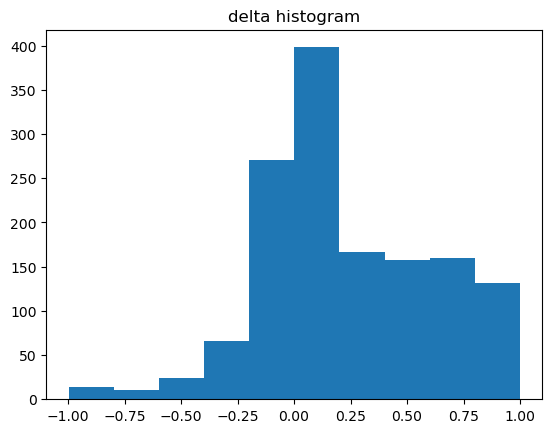

In [151]:
plt.hist(delta_df['delta'])
plt.title("delta histogram")

### **phi sum calculation**

In [174]:
# completeness property phi matrix --> (15, 56, 25, 144, 73, 6)
phi_data = []
# going thru each run batch (folder)
#for r in range(completeness_property_phi_matrix.shape[0]):
    #print(f"processing run index {r}")
r=0
# going thru each file in run batch
for f in range(completeness_property_phi_matrix.shape[1]):
    #print(f"  -> processing file index {f}")

    # going thru each sample in file 
    for s in range(completeness_property_phi_matrix.shape[2]):
        #print(f"    -> processing sample index {s}")
        
        # sum over lat, lon, vars
        #phi_val = np.sum(completeness_property_phi_matrix, axis=(3,4,5))
        phi_val = np.sum(completeness_property_phi_matrix[r, f, s]) # slice instead to 
        

        # append to make df 
        phi_data.append({
            'id': f"{r}_{f}_{s}",
            'phi': (phi_val)
        })

phi_df = pd.DataFrame(phi_data)

In [175]:
phi_df

,id,phi
0,0_0_0,0.359833
1,0_0_1,-0.206246
2,0_0_2,0.134631
3,0_0_3,0.180020
4,0_0_4,0.161413
...,...,...
1395,0_55_20,0.126469
1396,0_55_21,0.166051
1397,0_55_22,0.393615
1398,0_55_23,0.006624


In [176]:
delta_df

,id,delta
0,0_0_0,-0.080721
1,0_0_1,-0.080048
2,0_0_2,0.271530
3,0_0_3,0.262125
4,0_0_4,0.228930
...,...,...
1395,0_55_20,0.054356
1396,0_55_21,0.076957
1397,0_55_22,0.446499
1398,0_55_23,-0.057878


In [171]:
merged = pd.merge(delta_df, phi_df, on='id', how='inner')

In [172]:
print(f"Delta length: {len(delta_df)}")
print(f"Phi length: {len(phi_df)}")
print(f"Merged length: {len(merged)}")

Delta length: 1400
Phi length: 1400
Merged length: 1400


In [173]:
merged

,id,delta,phi
0,0_0_0,-0.080721,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1,0_0_1,-0.080048,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
2,0_0_2,0.271530,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
3,0_0_3,0.262125,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
4,0_0_4,0.228930,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
...,...,...,...
1395,0_55_20,0.054356,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1396,0_55_21,0.076957,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1397,0_55_22,0.446499,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1398,0_55_23,-0.057878,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."


In [157]:
len(merged['phi']) # 1 by 56 by 25

1400

In [158]:
merged['phi'][0]

array([[[ 0.35983348, -0.20624584,  0.13463101, ...,  0.30512083,
          0.19926633,  0.196728  ],
        [ 0.3997794 , -0.42984033,  0.32786086, ...,  0.46458158,
          0.321764  ,  0.40435946],
        [ 0.536516  ,  0.53894025,  0.52987164, ...,  0.54339975,
          0.535729  ,  0.54518306],
        ...,
        [ 0.60087967,  0.36537978,  0.06422447, ...,  0.532896  ,
          0.43069112, -0.02448058],
        [ 0.8765788 ,  0.9762681 ,  0.9449307 , ...,  0.9684928 ,
          0.98120606,  0.977433  ],
        [-0.06342611,  0.07815591, -0.06055078, ...,  0.39361468,
          0.00662407,  0.06357271]]], dtype=float32)

In [124]:
import plotly.express as px

px.scatter(merged, x='delta', y='phi'[0], hover_data=['id'])

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['id', 'delta', 'phi'] but received: p

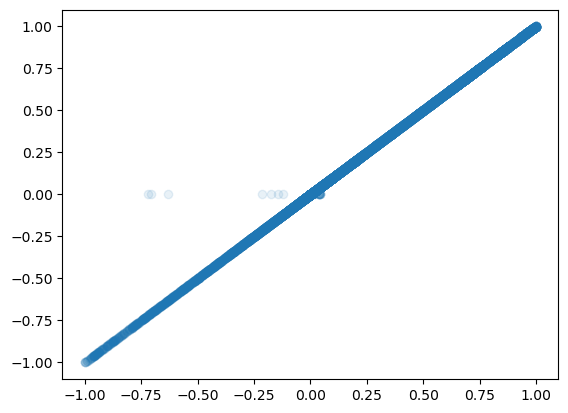

In [13]:
plt.scatter(merged_df['delta'], merged_df['phi'], alpha=0.1)

**horizontal line** = no change in phi sum (0) but changes in pred delta --> vanishing gradient issue
    - because this is where the early & late years are super different so pred delta has values, but IG did not track feature importance bc vanishing gradient (?)

**vertical line at delta value of 0.00** = no change in pred delta (0) but changes in phi sum --> similar climate scenarios
    - predicted close to early period, causing 0.0 pred delta but IG picked up on feature differences (internal noise that IG picked up on?)

**vertical line at delta value of 1.00** = no change in pred delta (1) but changes in phi sum --> super different climate scenarios
    - delta pred perfectly predicted 1.0 (late period), but IG did not pick up on the same amount of feature importance bc jump was too big? 


In [160]:
merged

,id,delta,phi
0,0_0_0,-0.080721,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1,0_0_1,-0.080048,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
2,0_0_2,0.271530,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
3,0_0_3,0.262125,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
4,0_0_4,0.228930,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
...,...,...,...
1395,0_55_20,0.054356,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1396,0_55_21,0.076957,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1397,0_55_22,0.446499,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."
1398,0_55_23,-0.057878,"[[[0.35983348, -0.20624584, 0.13463101, 0.1800..."


In [44]:
# looking at absolute error btwn delta and phi
merged['abs_error'] = (merged['delta'] - merged['phi']).abs()

sorted_df = merged.sort_values(by='abs_error', ascending=False)

sorted_df.head(10)

,id,delta,phi,abs_error
2202,1_32_2,0.728346,-0.417583,1.145929
2224,1_32_24,0.757134,-0.386492,1.143625
2162,1_30_12,0.719471,-0.405535,1.125006
2212,1_32_12,0.757120,-0.367748,1.124867
2217,1_32_17,0.757134,-0.364281,1.121415
2207,1_32_7,0.757069,-0.338576,1.095644
2215,1_32_15,0.757134,-0.337826,1.094960
2219,1_32_19,0.757103,-0.332604,1.089707
2216,1_32_16,0.757134,-0.319004,1.076137
2211,1_32_11,0.757113,-0.312301,1.069414


In [54]:
sorted_df

,id,delta,phi,abs_error
2202,1_32_2,0.728346,-0.417583,1.145929
2224,1_32_24,0.757134,-0.386492,1.143625
2162,1_30_12,0.719471,-0.405535,1.125006
2212,1_32_12,0.757120,-0.367748,1.124867
2217,1_32_17,0.757134,-0.364281,1.121415
...,...,...,...,...
241,0_9_16,0.000000,0.000000,0.000000
242,0_9_17,0.000000,0.000000,0.000000
244,0_9_19,0.000000,0.000000,0.000000
245,0_9_20,0.000000,0.000000,0.000000


In [45]:
from sklearn.metrics import r2_score, mean_absolute_error

# calculating r2 and mae from scikit-learn
r2 = r2_score(merged['delta'], merged['phi'])
mae = mean_absolute_error(merged['delta'], merged['phi'])

print(f"r squared value: {r2:.4f}")
print(f"MAE: {mae:.4f}")

r squared value: 0.6263
MAE: 0.1103


In [46]:
# threshold
epsilon = 0.05

# delta (x axis) close to 0 ish 
is_delta_zero = merged['delta'].abs() < epsilon

# look where phi is not 0 --> aka where the 1:1 points are 
is_phi_not_zero = merged['phi'].abs() > epsilon

# filter out merged df 
vertical_line_0 = merged[is_delta_zero & is_phi_not_zero]

vertical_line_0.head(10)

,id,delta,phi,abs_error
454,0_18_4,0.048843,0.050480,0.001637
1409,1_0_9,0.008558,-0.414741,0.423300
1458,1_2_8,-0.023551,0.484155,0.507706
1474,1_2_24,-0.033215,0.491987,0.525202
1475,1_3_0,-0.014703,0.306245,0.320948
1500,1_4_0,0.022026,0.509713,0.487687
1575,1_7_0,-0.046710,-0.171056,0.124346
1578,1_7_3,-0.047290,-0.239294,0.192005
1581,1_7_6,-0.030362,-0.081428,0.051066
1586,1_7_11,-0.044444,-0.404529,0.360086


In [47]:
# threshold
epsilon = 0.05

# delta (x axis) close to 1 ish 
is_delta_one = (merged['delta']-1.0).abs() < epsilon

# look where phi is not 1 --> aka where the 1:1 points are 
is_phi_not_one = merged['phi']< (1-epsilon)

# filter out merged df 
vertical_line_1 = merged[is_delta_one & is_phi_not_one]

vertical_line_1.head(10)

,id,delta,phi,abs_error
2702,1_52_2,0.965588,0.906760,0.058829
2703,1_52_3,0.973963,0.917730,0.056233
2706,1_52_6,0.964593,0.907505,0.057088
2708,1_52_8,0.979289,0.908292,0.070998
2709,1_52_9,0.979598,0.919683,0.059914
2710,1_52_10,0.963909,0.907980,0.055929
2711,1_52_11,0.964533,0.909944,0.054589
2712,1_52_12,0.979598,0.916133,0.063465
2714,1_52_14,0.979598,0.905869,0.073729
2715,1_52_15,0.979598,0.902833,0.076764


In [48]:
# threshold
epsilon = 0.05

# phi (y axis) close to 0 ish 
is_phi_zero = merged['phi'].abs() < epsilon

# look where delta is not 0 --> aka where the 1:1 points are 
is_delta_not_zero = merged['delta'].abs() > epsilon

# filter out merged df 
horizontal_line_0 = merged[is_delta_zero & is_phi_not_zero]

horizontal_line_0.head(10)

,id,delta,phi,abs_error
454,0_18_4,0.048843,0.050480,0.001637
1409,1_0_9,0.008558,-0.414741,0.423300
1458,1_2_8,-0.023551,0.484155,0.507706
1474,1_2_24,-0.033215,0.491987,0.525202
1475,1_3_0,-0.014703,0.306245,0.320948
1500,1_4_0,0.022026,0.509713,0.487687
1575,1_7_0,-0.046710,-0.171056,0.124346
1578,1_7_3,-0.047290,-0.239294,0.192005
1581,1_7_6,-0.030362,-0.081428,0.051066
1586,1_7_11,-0.044444,-0.404529,0.360086


In [49]:
# 1. Isolate the Vertical Line (Phi Sum is ~0)
# We use a small threshold (1e-6) because floating point math rarely hits exactly 0.0
vertical_line_samples = merged[merged['phi'].abs() < 1e-6]

# 2. Isolate the Horizontal Line (Delta is ~0)
horizontal_line_samples = merged[merged['delta'].abs() < 1e-6]

# 3. Print a summary to see if they share common traits
print(f"Number of samples in Vertical Line: {len(vertical_line_samples)}")
print(f"Number of samples in Horizontal Line: {len(horizontal_line_samples)}")

# Optional: Inspect the first few to see if they are from the same Run/File
print("Sample of vertical line data:")
print(vertical_line_samples.head())

Number of samples in Vertical Line: 16
Number of samples in Horizontal Line: 16
Sample of vertical line data:
        id  delta  phi  abs_error
225  0_9_0    0.0  0.0        0.0
228  0_9_3    0.0  0.0        0.0
229  0_9_4    0.0  0.0        0.0
231  0_9_6    0.0  0.0        0.0
232  0_9_7    0.0  0.0        0.0


In [50]:
vertical_line_samples

,id,delta,phi,abs_error
225,0_9_0,0.0,0.0,0.0
228,0_9_3,0.0,0.0,0.0
229,0_9_4,0.0,0.0,0.0
231,0_9_6,0.0,0.0,0.0
232,0_9_7,0.0,0.0,0.0
234,0_9_9,0.0,0.0,0.0
235,0_9_10,0.0,0.0,0.0
236,0_9_11,0.0,0.0,0.0
237,0_9_12,0.0,0.0,0.0
239,0_9_14,0.0,0.0,0.0


In [51]:
horizontal_line_samples

,id,delta,phi,abs_error
225,0_9_0,0.0,0.0,0.0
228,0_9_3,0.0,0.0,0.0
229,0_9_4,0.0,0.0,0.0
231,0_9_6,0.0,0.0,0.0
232,0_9_7,0.0,0.0,0.0
234,0_9_9,0.0,0.0,0.0
235,0_9_10,0.0,0.0,0.0
236,0_9_11,0.0,0.0,0.0
237,0_9_12,0.0,0.0,0.0
239,0_9_14,0.0,0.0,0.0
